In [3]:
# load packages for single cell scanpy analysis
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import anndata as ad
import datetime

In [4]:
# set up paths for files 
gene_exp = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression/matrix.csv" #intronic and exonic reads 
#exon_exp = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression/exon.csv" # exonic reads only 

# load gene expression data
# exon_exp_adata = sc.read_csv(exon_exp)
# print(f"Done reading {exon_exp}")
gene_exp_adata = sc.read_csv(gene_exp)
print(f"Done reading {gene_exp}")

Done reading /gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression/matrix.csv


In [9]:
adata = gene_exp_adata.copy()

In [5]:
# Transpose the adata object (exon reads only is not in the right format)
# exon_exp_adata = exon_exp_adata.transpose()
# print(exon_exp_adata.shape, gene_exp_adata.shape)
# check if any obs_names are the same between gene_exp and exon_exp considering not an equal number of cells in the two files
# print(set(exon_exp_adata.obs_names).intersection(set(gene_exp_adata.obs_names)))

In [10]:
# read in metadata
metadata = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/INFO/metadata.csv"
metadata = pd.read_csv(metadata)
# print every single column in the file 
# print(metadata.columns)
# print(metadata.region_label.value_counts()), print(metadata.subclass_label.value_counts())

In [11]:
WD="/gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression"
today = datetime.datetime.now()
today = today.strftime("%Y-%m-%d")

In [12]:
# Ensure metadata matches the cells in adata
if 'sample_name' in metadata.columns:
    metadata.set_index('sample_name', inplace=True)
    adata.obs = metadata.loc[adata.obs_names]  # Align metadata to the cells in adata
else:
    raise ValueError("Metadata must have a column named 'sample_name' to match with gene expression data.")

In [13]:
# Add "gene_name" column to adata.var
adata.var['gene_name'] = adata.var_names

# Set whether to run HVG only or not
run_hvg_only = True

# Make new directory in WD using today's date and run_hvg_only tag
if run_hvg_only:
    os.makedirs(f"{WD}/scanpy_{today}_hvg_only", exist_ok=True)
    os.chdir(f"{WD}/scanpy_{today}_hvg_only")
else:
    os.makedirs(f"{WD}/scanpy_{today}", exist_ok=True)
    os.chdir(f"{WD}/scanpy_{today}")

### Quick quality control

In [14]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

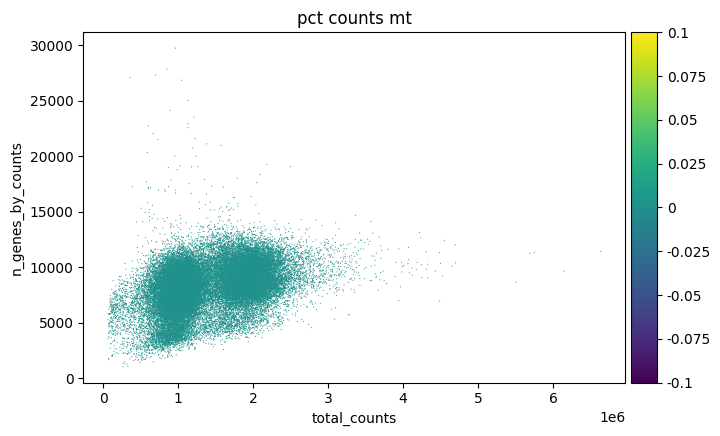

In [15]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [16]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=10)

print(f"Number of cells and genes after filtering: {adata.n_obs}, {adata.n_vars}")

Number of cells and genes after filtering: 49417, 46907


In [17]:
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
import anndata2ri

# Activate the automatic conversion of AnnData objects to/from Seurat objects
anndata2ri.activate()

# Import Seurat
seurat = importr('Seurat')

/scratch/ipykernel_6612/3290560500.py:7: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [20]:
# Convert AnnData to Seurat
with localconverter(ro.default_converter + anndata2ri.converter):
    adata = ro.conversion.py2rpy(adata)

### Normalize and filter data 

In [ ]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

# Normalize counts per cell to 10,000 reads per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform the normalized data
sc.pp.log1p(adata)

In [ ]:
# Find highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=5000, subset=False)

### Downstream clustering and UMAP with just HVG

In [ ]:
if run_hvg_only:
    # Subset HVGs for dimensionality reduction
    adata_hvg = adata[:, adata.var['highly_variable']].copy() 
    print(f"Obtained {adata_hvg.shape[1]} highly variable genes.")
else:
    adata_hvg = adata.copy()
    print(f"Using all {adata_hvg.shape[1]} genes.")

# Perform PCA and clustering
sc.tl.pca(adata_hvg)
print(f"Done with PCA. Explained variance: {adata_hvg.uns['pca']['variance_ratio'][:10]}")

sc.pp.neighbors(adata_hvg)
print("Done with neighborhood graph.")
sc.tl.leiden(adata_hvg)
print("Done with clustering.")
sc.tl.umap(adata_hvg)
print("Done with UMAP.")

In [ ]:
sc.pl.umap(adata_hvg, color=['leiden'])

Next, we want to load the tabula sapien data and see if macrophages/immune related cells share some similarities with immune cells in the Allen Brain dataset (although these are mainly neuronal)

In [ ]:
# I want to visualize neuronal vs non-neuronal cells
sc.pl.umap(adata_hvg, color=['subclass_label'])

In [ ]:
sc.pl.umap(
    adata_hvg,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

In [ ]:
sc.pl.umap(adata_hvg, color=['A2M', 'CX3CR1', 'P2RY12'])

In [ ]:
sc.pl.umap(adata_hvg, color=['region_label', 'class_label', 'cortical_layer_label'])

In [ ]:
adata_hvg.var.sort_values('dispersions_norm', ascending=False).head(10)

In [ ]:
sc.pl.umap(adata_hvg, color=['NPY', 'CD74'])

In [ ]:
# save this Anndata object for future use
anndata_filename = os.path.join(WD, f"adata_{today}_HVG_only_{run_hvg_only}.h5ad")
print(anndata_filename)
adata_hvg.write(anndata_filename)